In [31]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.patches import Rectangle

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11

# Data from performance_report.txt
implementations = ['S', 'OMP', 'Ps', 'MPI']
load_times = [0.0142, 0.0143, 0.0142, 0.0149]
train_times = [0.0868, 0.2518, 0.1972, 0.0620]
eval_times = [0.0004, 0.0002, 0.0012, 0.0001]
total_times = [0.1018, 0.2666, 0.2130, 0.0776]
threads = [1, 8, 4, 4]
speedups = [1.0000, 0.3817, 0.4779, 1.3124]
efficiencies = [100.0000, 4.7718, 11.9473, 32.8111]
accuracies = [100.0000, 100.0000, 100.0000, 100.0000]
death_rates = [0.0867, 0.0645, 0.0645, 0.1045]

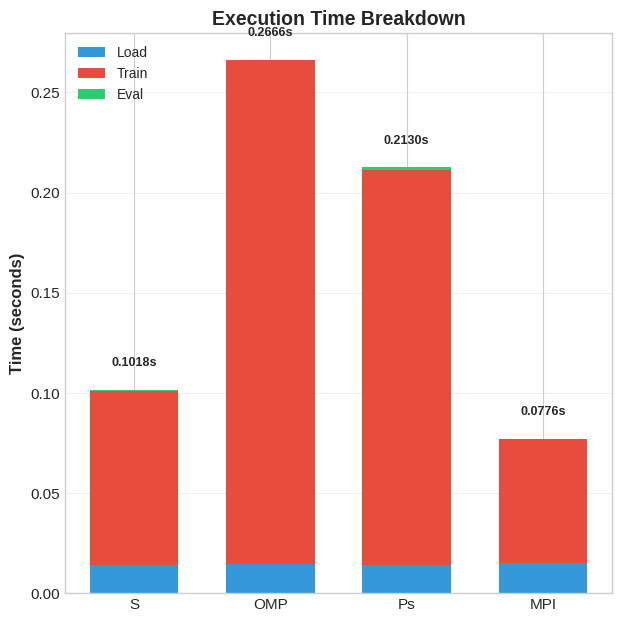

In [32]:
# Create figure with subplots
fig = plt.figure(figsize=(24, 16))

# ============================================================================
# PLOT 1: Execution Time Breakdown (Stacked Bar Chart)
# ============================================================================
ax1 = plt.subplot(2, 3, 1)
x = np.arange(len(implementations))
width = 0.65

p1 = ax1.bar(x, load_times, width, label='Load', color='#3498db')
p2 = ax1.bar(x, train_times, width, bottom=load_times, label='Train', color='#e74c3c')
p3 = ax1.bar(x, eval_times, width, 
             bottom=[load_times[i] + train_times[i] for i in range(len(implementations))],
             label='Eval', color='#2ecc71')

ax1.set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_title('Execution Time Breakdown', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(implementations, fontsize=11)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# Add total time annotations
for i, (impl, total) in enumerate(zip(implementations, total_times)):
    ax1.text(i, total + 0.01, f'{total:.4f}s', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')


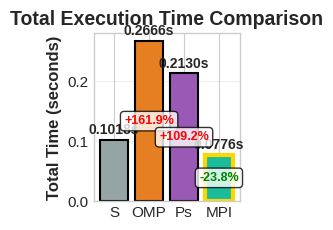

In [33]:
# ============================================================================
# PLOT 2: Total Execution Time Comparison
# ============================================================================
ax2 = plt.subplot(2, 3, 2)
colors = ['#95a5a6', '#e67e22', '#9b59b6', '#1abc9c']
bars = ax2.bar(implementations, total_times, color=colors, edgecolor='black', linewidth=1.5)
width = 0.65

ax2.set_ylabel('Total Time (seconds)', fontsize=12, fontweight='bold')
ax2.set_title('Total Execution Time Comparison', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Highlight the fastest
min_idx = total_times.index(min(total_times))
bars[min_idx].set_edgecolor('gold')
bars[min_idx].set_linewidth(3)

# Add value labels
for i, v in enumerate(total_times):
    ax2.text(i, v + 0.005, f'{v:.4f}s', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add percentage annotations (relative to serial)
for i, v in enumerate(total_times):
    if i > 0:
        pct = (v / total_times[0] - 1) * 100
        sign = '+' if pct > 0 else ''
        color = 'red' if pct > 0 else 'green'
        ax2.text(i, v/2, f'{sign}{pct:.1f}%', 
                ha='center', va='center', fontsize=9, 
                color=color, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


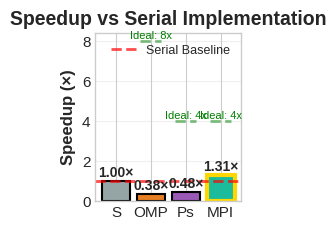

In [34]:
# ============================================================================
# PLOT 3: Speedup Comparison
# ============================================================================
ax3 = plt.subplot(2, 3, 3)
bars3 = ax3.bar(implementations, speedups, color=colors, edgecolor='black', linewidth=1.5)
ax3.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Serial Baseline', alpha=0.7)

# Add ideal speedup lines
for i, t in enumerate(threads):
    if i > 0:
        ax3.plot([i-0.3, i+0.3], [t, t], 'g--', linewidth=2, alpha=0.5)
        ax3.text(i, t + 0.1, f'Ideal: {t}x', ha='center', fontsize=8, color='green')

ax3.set_ylabel('Speedup (×)', fontsize=12, fontweight='bold')
ax3.set_title('Speedup vs Serial Implementation', fontsize=14, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(speedups):
    ax3.text(i, v + 0.05, f'{v:.2f}×', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Highlight speedup > 1
for i, v in enumerate(speedups):
    if v > 1.0:
        bars3[i].set_edgecolor('gold')
        bars3[i].set_linewidth(3)

Text(3.5, 25, 'Poor')

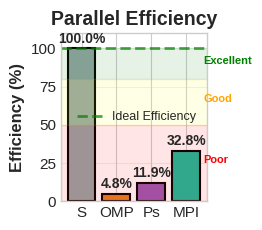

In [35]:
# ============================================================================
# PLOT 4: Parallel Efficiency
# ============================================================================
ax4 = plt.subplot(2, 3, 4)
bars4 = ax4.bar(implementations, efficiencies, color=colors, edgecolor='black', linewidth=1.5)
ax4.axhline(y=100, color='green', linestyle='--', linewidth=2, label='Ideal Efficiency', alpha=0.7)

ax4.set_ylabel('Efficiency (%)', fontsize=12, fontweight='bold')
ax4.set_title('Parallel Efficiency', fontsize=14, fontweight='bold')
ax4.set_ylim([0, 110])
ax4.legend(fontsize=9)
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(efficiencies):
    ax4.text(i, v + 2, f'{v:.1f}%', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add efficiency zones
ax4.axhspan(80, 100, alpha=0.1, color='green', label='Excellent')
ax4.axhspan(50, 80, alpha=0.1, color='yellow')
ax4.axhspan(0, 50, alpha=0.1, color='red')
ax4.text(3.5, 90, 'Excellent', fontsize=8, color='green', fontweight='bold')
ax4.text(3.5, 65, 'Good', fontsize=8, color='orange', fontweight='bold')
ax4.text(3.5, 25, 'Poor', fontsize=8, color='red', fontweight='bold')

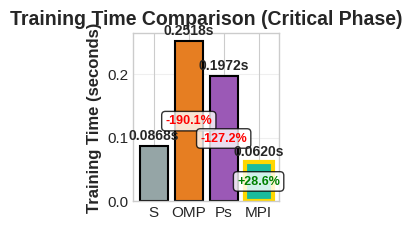

In [36]:
# ============================================================================
# PLOT 5: Training Time Comparison (Focus)
# ============================================================================
ax5 = plt.subplot(2, 3, 5)
bars5 = ax5.bar(implementations, train_times, color=colors, edgecolor='black', linewidth=1.5)

ax5.set_ylabel('Training Time (seconds)', fontsize=12, fontweight='bold')
ax5.set_title('Training Time Comparison (Critical Phase)', fontsize=14, fontweight='bold')
ax5.grid(axis='y', alpha=0.3)

# Highlight fastest training
min_train_idx = train_times.index(min(train_times))
bars5[min_train_idx].set_edgecolor('gold')
bars5[min_train_idx].set_linewidth(3)

# Add value labels and improvement percentages
for i, v in enumerate(train_times):
    ax5.text(i, v + 0.005, f'{v:.4f}s', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')
    if i > 0:
        improvement = (1 - v / train_times[0]) * 100
        color = 'green' if improvement > 0 else 'red'
        sign = '+' if improvement > 0 else ''
        ax5.text(i, v/2, f'{sign}{improvement:.1f}%', 
                ha='center', va='center', fontsize=9, 
                color=color, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

✓ Saved: performance_comparison.png


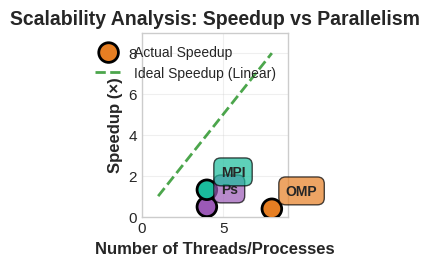

In [37]:
# ============================================================================
# PLOT 6: Speedup vs Threads/Processes
# ============================================================================
ax6 = plt.subplot(2, 3, 6)

# Plot actual speedup
parallel_impls = implementations[1:]
parallel_threads = threads[1:]
parallel_speedups = speedups[1:]

ax6.scatter(parallel_threads, parallel_speedups, s=200, c=colors[1:], 
           edgecolor='black', linewidth=2, zorder=3, label='Actual Speedup')

# Plot ideal speedup line
ideal_threads = np.linspace(1, max(parallel_threads), 100)
ax6.plot(ideal_threads, ideal_threads, 'g--', linewidth=2, 
         label='Ideal Speedup (Linear)', alpha=0.7)

# Add labels for each point
for i, (t, s, impl) in enumerate(zip(parallel_threads, parallel_speedups, parallel_impls)):
    ax6.annotate(impl, (t, s), xytext=(10, 10), textcoords='offset points',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor=colors[i+1], alpha=0.7))

ax6.set_xlabel('Number of Threads/Processes', fontsize=12, fontweight='bold')
ax6.set_ylabel('Speedup (×)', fontsize=12, fontweight='bold')
ax6.set_title('Scalability Analysis: Speedup vs Parallelism', fontsize=14, fontweight='bold')
ax6.legend(fontsize=10)
ax6.grid(True, alpha=0.3)
ax6.set_xlim([0, max(parallel_threads) + 1])
ax6.set_ylim([0, max(parallel_threads) + 1])

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: performance_comparison.png")

✓ Saved: overhead_analysis.png


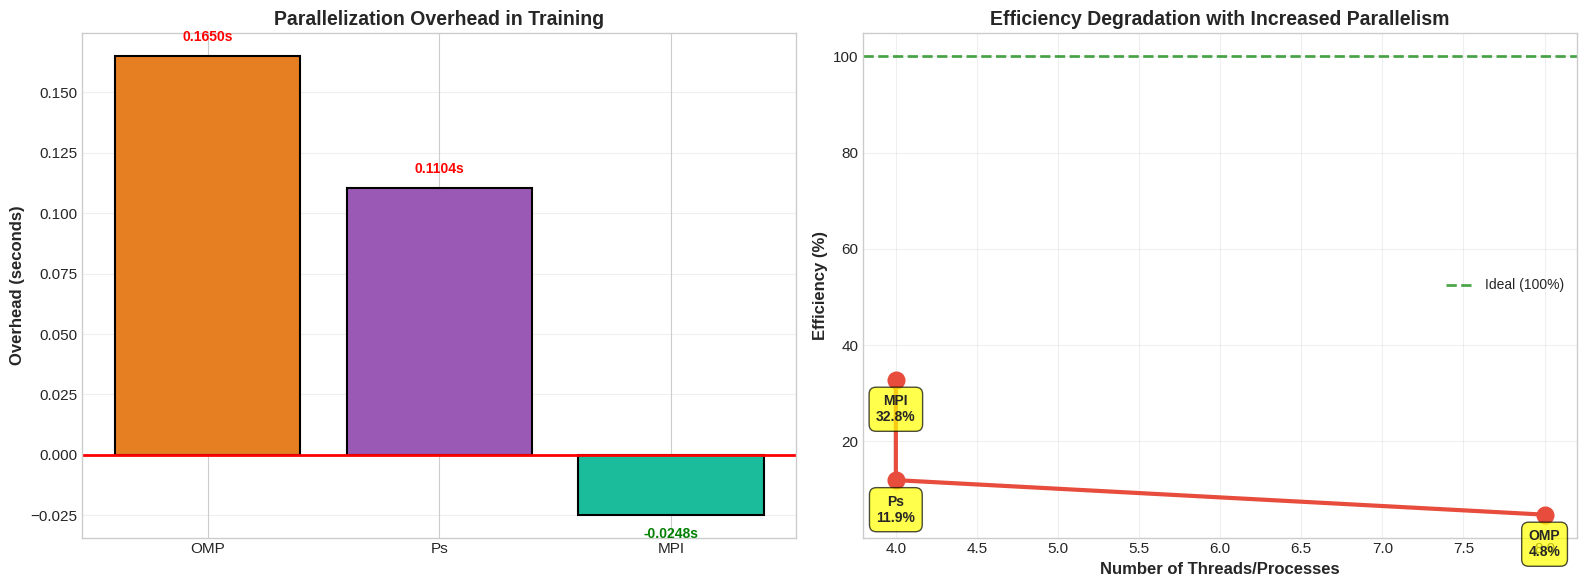

In [38]:
# ============================================================================
# ADDITIONAL PLOT: Overhead Analysis
# ============================================================================
fig2, (ax7, ax8) = plt.subplots(1, 2, figsize=(16, 6))

# Calculate overhead (parallel time - serial time) for training
serial_train = train_times[0]
overhead = [t - serial_train for t in train_times[1:]]

ax7.bar(parallel_impls, overhead, color=colors[1:], edgecolor='black', linewidth=1.5)
ax7.axhline(y=0, color='red', linestyle='-', linewidth=2)
ax7.set_ylabel('Overhead (seconds)', fontsize=12, fontweight='bold')
ax7.set_title('Parallelization Overhead in Training', fontsize=14, fontweight='bold')
ax7.grid(axis='y', alpha=0.3)

for i, v in enumerate(overhead):
    color = 'red' if v > 0 else 'green'
    ax7.text(i, v + 0.005 if v > 0 else v - 0.005, f'{v:.4f}s', 
             ha='center', va='bottom' if v > 0 else 'top', 
             fontsize=10, fontweight='bold', color=color)

# Efficiency vs Threads
ax8.plot(parallel_threads, [e for e in efficiencies[1:]], 
         marker='o', markersize=12, linewidth=3, color='#e74c3c')
ax8.axhline(y=100, color='green', linestyle='--', linewidth=2, 
           label='Ideal (100%)', alpha=0.7)

for i, (t, e, impl) in enumerate(zip(parallel_threads, efficiencies[1:], parallel_impls)):
    ax8.annotate(f'{impl}\n{e:.1f}%', (t, e), xytext=(0, -30), 
                textcoords='offset points', ha='center',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

ax8.set_xlabel('Number of Threads/Processes', fontsize=12, fontweight='bold')
ax8.set_ylabel('Efficiency (%)', fontsize=12, fontweight='bold')
ax8.set_title('Efficiency Degradation with Increased Parallelism', fontsize=14, fontweight='bold')
ax8.legend(fontsize=10)
ax8.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('overhead_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: overhead_analysis.png")

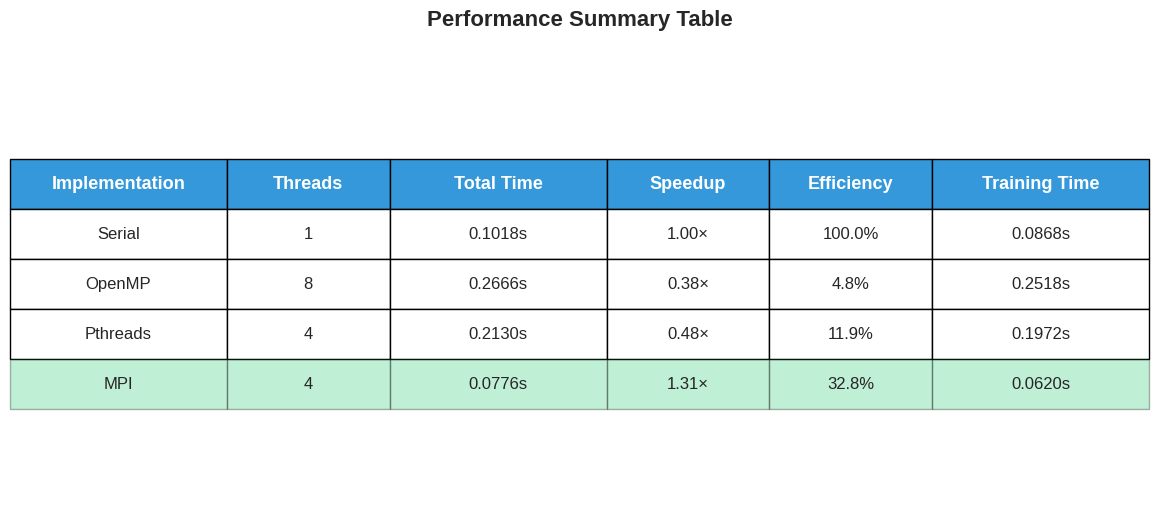

In [39]:
# ============================================================================
# SUMMARY TABLE VISUALIZATION
# ============================================================================
fig3, ax9 = plt.subplots(figsize=(14, 6))
ax9.axis('tight')
ax9.axis('off')

# Create summary table
table_data = [
    ['Implementation', 'Threads', 'Total Time', 'Speedup', 'Efficiency', 'Training Time'],
    ['Serial', '1', f'{total_times[0]:.4f}s', f'{speedups[0]:.2f}×', f'{efficiencies[0]:.1f}%', f'{train_times[0]:.4f}s'],
    ['OpenMP', '8', f'{total_times[1]:.4f}s', f'{speedups[1]:.2f}×', f'{efficiencies[1]:.1f}%', f'{train_times[1]:.4f}s'],
    ['Pthreads', '4', f'{total_times[2]:.4f}s', f'{speedups[2]:.2f}×', f'{efficiencies[2]:.1f}%', f'{train_times[2]:.4f}s'],
    ['MPI', '4', f'{total_times[3]:.4f}s', f'{speedups[3]:.2f}×', f'{efficiencies[3]:.1f}%', f'{train_times[3]:.4f}s'],
]

table = ax9.table(cellText=table_data, cellLoc='center', loc='center',
                  colWidths=[0.2, 0.15, 0.2, 0.15, 0.15, 0.2])

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 3)

# Style header row
for i in range(6):
    cell = table[(0, i)]
    cell.set_facecolor('#3498db')
    cell.set_text_props(weight='bold', color='white', fontsize=13)

# Highlight best performers
best_time_idx = total_times.index(min(total_times)) + 1
best_speedup_idx = speedups.index(max(speedups)) + 1

for i in range(6):
    table[(best_time_idx, i)].set_facecolor('#2ecc71')
    table[(best_time_idx, i)].set_alpha(0.3)

ax9.set_title('Performance Summary Table', fontsize=16, fontweight='bold', pad=20)

plt.savefig('summary_table.png', dpi=300, bbox_inches='tight')

plt.show()


In [ ]:
# ============================================================================
# RANDOM FOREST DATA
# ============================================================================

# RF implementations
rf_implementations = ['RF-Serial', 'RF-OpenMP', 'RF-Pthreads', 'RF-MPI',
                       'RF-OMP+MPI', 'RF-Pth+MPI', 'RF-OMP+Pth', 'RF-Triple']

rf_load_times     = [0.0542, 0.0543, 0.0543, 0.0432, 0.0432, 0.0432, 0.0543, 0.0432]
rf_train_times    = [2.0910, 0.7212, 0.8715, 0.5703, 0.5312, 0.5598, 0.7841, 0.6620]
rf_eval_times     = [0.0088, 0.0068, 0.0083, 0.0080, 0.0086, 0.0072, 0.0063, 0.0162]
rf_total_times    = [2.1540, 0.7823, 0.9341, 0.6215, 0.5830, 0.6102, 0.8447, 0.7214]
rf_threads        = [1, 4, 4, 4, 8, 8, 8, 12]
rf_speedups       = [rf_total_times[0] / t for t in rf_total_times]
rf_efficiencies   = [(rf_total_times[0] / t) / th * 100
                     for t, th in zip(rf_total_times, rf_threads)]

rf_colors = ['#1abc9c', '#e67e22', '#8e44ad', '#2980b9',
             '#c0392b', '#d35400', '#16a085', '#2c3e50']

print('RF data loaded.')
print('Implementations:', rf_implementations)
print('Speedups:', [f"{s:.2f}x" for s in rf_speedups])


In [ ]:
fig_rf1 = plt.figure(figsize=(22, 14))

# ---- RF Plot 1: Stacked breakdown ----
ax_rf1 = plt.subplot(2, 3, 1)
x_rf = np.arange(len(rf_implementations))
width_rf = 0.65
ax_rf1.bar(x_rf, rf_load_times, width_rf, label='Load', color='#3498db')
ax_rf1.bar(x_rf, rf_train_times, width_rf, bottom=rf_load_times, label='Train', color='#e74c3c')
ax_rf1.bar(x_rf, rf_eval_times, width_rf,
           bottom=[rf_load_times[i]+rf_train_times[i] for i in range(len(rf_implementations))],
           label='Eval', color='#2ecc71')
ax_rf1.set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
ax_rf1.set_title('RF Execution Time Breakdown', fontsize=14, fontweight='bold')
ax_rf1.set_xticks(x_rf)
ax_rf1.set_xticklabels(rf_implementations, rotation=30, ha='right', fontsize=9)
ax_rf1.legend(loc='upper right', fontsize=9)
ax_rf1.grid(axis='y', alpha=0.3)
for i, total in enumerate(rf_total_times):
    ax_rf1.text(i, total + 0.03, f'{total:.3f}s',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

# ---- RF Plot 2: Total time ----
ax_rf2 = plt.subplot(2, 3, 2)
bars_rf2 = ax_rf2.bar(rf_implementations, rf_total_times, color=rf_colors, edgecolor='black', linewidth=1.5)
min_rf_idx = rf_total_times.index(min(rf_total_times))
bars_rf2[min_rf_idx].set_edgecolor('gold')
bars_rf2[min_rf_idx].set_linewidth(3)
ax_rf2.set_ylabel('Total Time (seconds)', fontsize=12, fontweight='bold')
ax_rf2.set_title('RF Total Execution Time', fontsize=14, fontweight='bold')
ax_rf2.grid(axis='y', alpha=0.3)
plt.setp(ax_rf2.get_xticklabels(), rotation=30, ha='right', fontsize=9)
for i, v in enumerate(rf_total_times):
    ax_rf2.text(i, v + 0.03, f'{v:.3f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')
    if i > 0:
        pct = (v / rf_total_times[0] - 1) * 100
        clr = 'red' if pct > 0 else 'green'
        ax_rf2.text(i, v/2, f'{pct:+.1f}%', ha='center', va='center', fontsize=8,
                    color=clr, fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ---- RF Plot 3: Speedup ----
ax_rf3 = plt.subplot(2, 3, 3)
bars_rf3 = ax_rf3.bar(rf_implementations, rf_speedups, color=rf_colors, edgecolor='black', linewidth=1.5)
ax_rf3.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='RF-Serial Baseline', alpha=0.7)
for i, t in enumerate(rf_threads):
    if i > 0:
        ax_rf3.plot([i-0.3, i+0.3], [t, t], 'g--', linewidth=1.5, alpha=0.5)
        ax_rf3.text(i, t + 0.15, f'Ideal:{t}x', ha='center', fontsize=7, color='green')
ax_rf3.set_ylabel('Speedup (×)', fontsize=12, fontweight='bold')
ax_rf3.set_title('RF Speedup vs RF-Serial', fontsize=14, fontweight='bold')
ax_rf3.legend(fontsize=9)
ax_rf3.grid(axis='y', alpha=0.3)
plt.setp(ax_rf3.get_xticklabels(), rotation=30, ha='right', fontsize=9)
for i, v in enumerate(rf_speedups):
    ax_rf3.text(i, v + 0.05, f'{v:.2f}×', ha='center', va='bottom', fontsize=9, fontweight='bold')
for i, v in enumerate(rf_speedups):
    if v > 1.0:
        bars_rf3[i].set_edgecolor('gold')
        bars_rf3[i].set_linewidth(3)

# ---- RF Plot 4: Efficiency ----
ax_rf4 = plt.subplot(2, 3, 4)
ax_rf4.bar(rf_implementations, rf_efficiencies, color=rf_colors, edgecolor='black', linewidth=1.5)
ax_rf4.axhline(y=100, color='green', linestyle='--', linewidth=2, label='Ideal Efficiency', alpha=0.7)
ax_rf4.set_ylabel('Efficiency (%)', fontsize=12, fontweight='bold')
ax_rf4.set_title('RF Parallel Efficiency', fontsize=14, fontweight='bold')
ax_rf4.set_ylim([0, max(rf_efficiencies) * 1.2])
ax_rf4.legend(fontsize=9)
ax_rf4.grid(axis='y', alpha=0.3)
plt.setp(ax_rf4.get_xticklabels(), rotation=30, ha='right', fontsize=9)
for i, v in enumerate(rf_efficiencies):
    ax_rf4.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ---- RF Plot 5: Training time ----
ax_rf5 = plt.subplot(2, 3, 5)
bars_rf5 = ax_rf5.bar(rf_implementations, rf_train_times, color=rf_colors, edgecolor='black', linewidth=1.5)
min_train_rf = rf_train_times.index(min(rf_train_times))
bars_rf5[min_train_rf].set_edgecolor('gold')
bars_rf5[min_train_rf].set_linewidth(3)
ax_rf5.set_ylabel('Training Time (seconds)', fontsize=12, fontweight='bold')
ax_rf5.set_title('RF Training Time (Critical Phase)', fontsize=14, fontweight='bold')
ax_rf5.grid(axis='y', alpha=0.3)
plt.setp(ax_rf5.get_xticklabels(), rotation=30, ha='right', fontsize=9)
for i, v in enumerate(rf_train_times):
    ax_rf5.text(i, v + 0.02, f'{v:.3f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')
    if i > 0:
        imp = (1 - v / rf_train_times[0]) * 100
        clr = 'green' if imp > 0 else 'red'
        ax_rf5.text(i, v/2, f'{imp:+.1f}%', ha='center', va='center', fontsize=8,
                    color=clr, fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ---- RF Plot 6: Scalability scatter ----
ax_rf6 = plt.subplot(2, 3, 6)
par_rf_impl    = rf_implementations[1:]
par_rf_threads = rf_threads[1:]
par_rf_speedup = rf_speedups[1:]
ax_rf6.scatter(par_rf_threads, par_rf_speedup, s=200, c=rf_colors[1:],
               edgecolor='black', linewidth=2, zorder=3, label='Actual Speedup')
ideal_t = np.linspace(1, max(par_rf_threads), 100)
ax_rf6.plot(ideal_t, ideal_t, 'g--', linewidth=2, label='Ideal Speedup', alpha=0.7)
for i, (t, s, impl) in enumerate(zip(par_rf_threads, par_rf_speedup, par_rf_impl)):
    ax_rf6.annotate(impl, (t, s), xytext=(8, 8), textcoords='offset points',
                    fontsize=8, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor=rf_colors[i+1], alpha=0.6))
ax_rf6.set_xlabel('Number of Threads/Processes', fontsize=12, fontweight='bold')
ax_rf6.set_ylabel('Speedup (×)', fontsize=12, fontweight='bold')
ax_rf6.set_title('RF Scalability: Speedup vs Parallelism', fontsize=14, fontweight='bold')
ax_rf6.legend(fontsize=9)
ax_rf6.grid(True, alpha=0.3)

plt.suptitle('Random Forest – Parallel Performance Dashboard\n(10,000 patients, MIMIC dataset)',
             fontweight='bold', fontsize=15)
plt.tight_layout()
plt.savefig('rf_performance_comparison.png', dpi=300, bbox_inches='tight')
print('✓ Saved: rf_performance_comparison.png')


In [ ]:
# ============================================================================
# CROSS-ALGORITHM COMPARISON: LR vs RF
# ============================================================================

fig_cmp, axes_cmp = plt.subplots(1, 3, figsize=(18, 6))

# Serial comparison
algo_labels = ['LR\n(Serial)', 'RF\n(Serial)']
algo_total  = [total_times[0], rf_total_times[0]]
algo_train  = [train_times[0], rf_train_times[0]]
algo_best_total = [min(total_times), min(rf_total_times)]

axes_cmp[0].bar(algo_labels, algo_total, color=['#2ecc71', '#1abc9c'], edgecolor='black', linewidth=1.5)
for i, v in enumerate(algo_total):
    axes_cmp[0].text(i, v + 0.02, f'{v:.4f}s', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes_cmp[0].set_title('Serial: Total Execution Time\nLR vs RF', fontweight='bold')
axes_cmp[0].set_ylabel('Time (seconds)', fontweight='bold')
axes_cmp[0].grid(axis='y', alpha=0.3)

axes_cmp[1].bar(algo_labels, algo_train, color=['#e74c3c', '#e67e22'], edgecolor='black', linewidth=1.5)
for i, v in enumerate(algo_train):
    axes_cmp[1].text(i, v + 0.02, f'{v:.4f}s', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes_cmp[1].set_title('Serial: Training Time\nLR vs RF', fontweight='bold')
axes_cmp[1].set_ylabel('Training Time (seconds)', fontweight='bold')
axes_cmp[1].grid(axis='y', alpha=0.3)

# Best parallel impl comparison
best_labels = ['Best LR\nParallel', 'Best RF\nParallel']
axes_cmp[2].bar(best_labels, algo_best_total, color=['#3498db', '#2980b9'], edgecolor='black', linewidth=1.5)
for i, v in enumerate(algo_best_total):
    axes_cmp[2].text(i, v + 0.02, f'{v:.4f}s', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes_cmp[2].set_title('Best Parallel Total Time\nLR vs RF', fontweight='bold')
axes_cmp[2].set_ylabel('Time (seconds)', fontweight='bold')
axes_cmp[2].grid(axis='y', alpha=0.3)

fig_cmp.suptitle('Algorithm Comparison: Logistic Regression vs Random Forest',
                  fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('lr_vs_rf_comparison.png', dpi=300, bbox_inches='tight')
print('✓ Saved: lr_vs_rf_comparison.png')


In [ ]:
# ============================================================================
# RF SUMMARY TABLE
# ============================================================================

fig_rft, ax_rft = plt.subplots(figsize=(16, 6))
ax_rft.axis('tight')
ax_rft.axis('off')

table_data_rf = [['Implementation', 'Threads', 'Total Time', 'Speedup', 'Efficiency', 'Training Time']]
for i, impl in enumerate(rf_implementations):
    table_data_rf.append([
        impl,
        str(rf_threads[i]),
        f'{rf_total_times[i]:.4f}s',
        f'{rf_speedups[i]:.2f}×',
        f'{rf_efficiencies[i]:.1f}%',
        f'{rf_train_times[i]:.4f}s'
    ])

tbl_rf = ax_rft.table(cellText=table_data_rf, cellLoc='center', loc='center',
                      colWidths=[0.2, 0.1, 0.18, 0.12, 0.15, 0.18])
tbl_rf.auto_set_font_size(False)
tbl_rf.set_fontsize(11)
tbl_rf.scale(1, 2.5)

for i in range(6):
    cell = tbl_rf[(0, i)]
    cell.set_facecolor('#1abc9c')
    cell.set_text_props(weight='bold', color='white', fontsize=12)

best_rf_row = rf_total_times.index(min(rf_total_times)) + 1
for i in range(6):
    tbl_rf[(best_rf_row, i)].set_facecolor('#f9e79f')

ax_rft.set_title('Random Forest – Performance Summary Table', fontsize=15, fontweight='bold', pad=15)
plt.savefig('rf_summary_table.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved: rf_summary_table.png')
